In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/16"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第16章 連続潜在変数 (Continuous Latent Variables)
## 16.3 証拠下界 (Evidence Lower Bound: ELBO)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第16章「連続潜在変数」の第16.3節「証拠下界 (Evidence Lower Bound)」の完全な理論解説、数式展開、Python実装、および忠実な図版再現（Figure 16.10）を提供します。

---

### 目次
1. **はじめに：なぜ連続潜在変数モデルにEMアルゴリズムを適用するのか？**
   - 閉形式解が存在するPPCAにおいて反復法を用いる計算論的動機
   - 高次元空間における計算量低減 $\mathcal{O}(D^3) \to \mathcal{O}(NDM)$
   - 欠損値（Missing Data）への自然な拡張
2. **16.3.1 期待値最大化法 (Expectation Maximization: EM)**
   - 完全データ対数尤度関数の定義（式 16.64）
   - 潜在変数事後分布による期待完全データ対数尤度の導出（式 16.65）
   - Eステップ：十分統計量 $\mathbb{E}[\mathbf{z}_n]$ と $\mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top]$ の計算（式 16.66, 16.67）
   - Mステップ：$\mathbf{W}_{\text{new}}$ と $\sigma_{\text{new}}^2$ の更新公式（式 16.68, 16.69）
   - オンラインEMおよびストリーミング処理
3. **16.3.2 主成分分析のためのEMアルゴリズム (EM for PCA)**
   - ゼロノイズ極限 $\sigma^2 \to 0$ による決定論的PCAの導出
   - 行列形式による簡潔なEステップとMステップ（式 16.70, 16.71）
   - 棒とバネ（フックの法則）による物理的メタファー
   - 合成データにおける反復推移の可視化（Figure 16.10 a 〜 f）
4. **16.3.3 因子分析のためのEMアルゴリズム (EM for Factor Analysis)**
   - 閉形式解が存在しない因子分析における反復学習の必然性
   - ウッドベリー公式を用いた反転行列 $\mathbf{G} = (\mathbf{I} + \mathbf{W}^\top \mathbf{\Psi}^{-1}\mathbf{W})^{-1}$（式 16.74）
   - 因子分析のEステップ（式 16.72, 16.73）
   - 因子分析のMステップ：因子負荷量 $\mathbf{W}$ と独自性 $\mathbf{\Psi}$ の更新（式 16.75, 16.76）
5. **応用実証：欠損値補完 (Missing Data Imputation)**
   - 観測成分と欠損成分の条件付きガウス分割
   - EMを用いた欠損画像・欠損センサデータの高精度復元


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "16" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.evidence_lower_bound_continuous import (
    ProbabilisticPCA_EM,
    StandardPCA_EM,
    FactorAnalysis_EM,
    generate_figure_16_10,
    FIG16_10_DATA,
)
from common.probabilistic_latent_variables import ProbabilisticPCA

setup_style()
print("Setup complete. Chapter 16 Section 16.3 modules loaded successfully.")


Setup complete. Chapter 16 Section 16.3 modules loaded successfully.


## 1. 16.3.1 期待値最大化法 (Expectation Maximization: EM)

前節（16.2節）では、確率的主成分分析 (PPCA) の最尤推定解 $\mathbf{W}_{\text{ML}}$ および $\sigma_{\text{ML}}^2$ について、標本共分散行列 $\mathbf{S}$ の固有値分解に基づく**厳密な閉形式解（closed-form solution）**（式 16.46, 16.47）が得られることを見ました。

一見すると、閉形式解が存在するにもかかわらず反復法であるEMアルゴリズムを用いるのは無意味であるように思われるかもしれません。しかし、実世界の高次元大規模機械学習において、EMアルゴリズムは決定的なアドバンテージを発揮します：

1. **計算量の大幅な節約**:
   - 標本共分散行列 $\mathbf{S}$ の構築には $\mathcal{O}(ND^2)$、その全固有値分解には $\mathcal{O}(D^3)$ の計算量を要します。
   - 次元数 $D$ が数十万〜数百万（ゲノムデータ、超高解像度画像、大規模言語埋め込みなど）で、求めたい主成分数 $M$ が小さい場合（$M \ll D$）、$\mathbf{S}$ を明示的に計算することすらメモリ上不可能です。
   - EMアルゴリズムは共分散行列 $\mathbf{S}$ を一切構築せず、データ行列との直接積によって1イテレーションあたり $\mathcal{O}(NDM)$ で動作します。
2. **オンライン学習・ストリーミング処理**:
   - 各データ点 $\mathbf{x}_n$ ごとにEステップの十分統計量を計算し、Mステップの和を逐次蓄積（インクリメンタル更新）できるため、全データをメモリに保持することなく処理可能。
3. **欠損値 (Missing Values) への自然な対応**:
   - 観測データに欠損成分がある場合、潜在変数 $\mathbf{z}$ と共に未観測変数を事後確率で重み付けて周辺化することで、EMの枠組みで欠損値を原理的に補完可能。
4. **因子分析への拡張**:
   - 因子分析モデル（16.2.4項）には閉形式の最尤解が存在しないため、EMアルゴリズムが唯一の実用的な最尤推定手段となる。

---

### EMアルゴリズムの厳密導出 (Derivation Steps)

第15章（15.3節）のEMアルゴリズムの一般的枠組みに従い、潜在変数 $\mathbf{Z} = \{\mathbf{z}_1, \dots, \mathbf{z}_N\}$ を導入した完全データ対数尤度関数 $\ln p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\mu}, \mathbf{W}, \sigma^2)$ を定式化します。
データ点群が互いに独立であることから：

$$
\ln p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\mu}, \mathbf{W}, \sigma^2) = \sum_{n=1}^N \left\{ \ln p(\mathbf{x}_n \mid \mathbf{z}_n) + \ln p(\mathbf{z}_n) \right\} \tag{16.64}
$$

最尤平均ベクトルは標本平均 $\boldsymbol{\mu} = \bar{\mathbf{x}}$ で確定しているため、これを代入します。
式 (16.31) の事前分布 $p(\mathbf{z}_n) = \mathcal{N}(\mathbf{z}_n \mid \mathbf{0}, \mathbf{I})$ および式 (16.32) の条件付き分布 $p(\mathbf{x}_n \mid \mathbf{z}_n) = \mathcal{N}(\mathbf{x}_n \mid \mathbf{W}\mathbf{z}_n + \bar{\mathbf{x}}, \sigma^2 \mathbf{I})$ を代入し、旧パラメータ値で評価した事後分布 $p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\mu}, \mathbf{W}^{\text{old}}, (\sigma^2)^{\text{old}})$ に関する期待値をとると、期待完全データ対数尤度 $Q(\boldsymbol{\theta}, \boldsymbol{\theta}^{\text{old}}) = \mathbb{E}_{\mathbf{Z}|\mathbf{X}}[\ln p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\theta})]$（証拠下界 ELBO）が得られます：

$$
\begin{aligned}
\mathbb{E}\left[\ln p(\mathbf{X}, \mathbf{Z} \mid \bar{\mathbf{x}}, \mathbf{W}, \sigma^2)\right] = -\sum_{n=1}^N \Biggl\{ & \frac{D}{2}\ln(2\pi\sigma^2) + \frac{1}{2}\operatorname{Tr}\left(\mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top]\right) + \frac{1}{2\sigma^2}\|\mathbf{x}_n - \bar{\mathbf{x}}\|^2 \\
& - \frac{1}{\sigma^2}\mathbb{E}[\mathbf{z}_n]^\top \mathbf{W}^\top (\mathbf{x}_n - \bar{\mathbf{x}}) + \frac{1}{2\sigma^2}\operatorname{Tr}\left(\mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top]\mathbf{W}^\top \mathbf{W}\right) + \frac{M}{2}\ln(2\pi) \Biggr\} \tag{16.65}
\end{aligned}
$$

この期待値は、潜在変数のガウス事後分布の1次および2次の**十分統計量（sufficient statistics）** $\mathbb{E}[\mathbf{z}_n]$ および $\mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top]$ のみを通じて依存しています。

---

### Eステップ (Expectation Step)

旧パラメータ $\mathbf{W}, \sigma^2$ を固定し、事後分布 (16.43) を用いて各データ点の統計量を計算します：

$$
\mathbb{E}[\mathbf{z}_n] = \mathbf{M}^{-1}\mathbf{W}^\top (\mathbf{x}_n - \bar{\mathbf{x}}) \tag{16.66}
$$

$$
\mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top] = \sigma^2 \mathbf{M}^{-1} + \mathbb{E}[\mathbf{z}_n]\mathbb{E}[\mathbf{z}_n]^\top \tag{16.67}
$$

ここで $\mathbf{M} = \mathbf{W}^\top \mathbf{W} + \sigma^2 \mathbf{I}_M$ です。

---

### Mステップ (Maximization Step)

統計量 $\mathbb{E}[\mathbf{z}_n]$ および $\mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top]$ を固定したまま、式 (16.65) を新パラメータ $\mathbf{W}$ および $\sigma^2$ に関して最大化します。
行列微分の公式 $\frac{\partial}{\partial \mathbf{W}}\operatorname{Tr}(\mathbf{A}\mathbf{W}^\top \mathbf{W}) = 2\mathbf{W}\mathbf{A}$ を用いて微分を 0 と置くことで、更新公式が得られます：

$$
\mathbf{W}_{\text{new}} = \left[\sum_{n=1}^N (\mathbf{x}_n - \bar{\mathbf{x}})\mathbb{E}[\mathbf{z}_n]^\top\right] \left[\sum_{n=1}^N \mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top]\right]^{-1} \tag{16.68}
$$

$$
\sigma_{\text{new}}^2 = \frac{1}{ND}\sum_{n=1}^N \left\{ \|\mathbf{x}_n - \bar{\mathbf{x}}\|^2 - 2\mathbb{E}[\mathbf{z}_n]^\top \mathbf{W}_{\text{new}}^\top (\mathbf{x}_n - \bar{\mathbf{x}}) + \operatorname{Tr}\left(\mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top]\mathbf{W}_{\text{new}}^\top \mathbf{W}_{\text{new}}\right) \right\} \tag{16.69}
$$


In [2]:
# PPCA の EM アルゴリズム実行と対数尤度の単調増加検証
rng = np.random.default_rng(42)
N, D, M = 250, 6, 2
Z_true = rng.standard_normal((N, M))
W_true = rng.standard_normal((D, M))
mu_true = rng.standard_normal(D)
sigma_true = 0.35
X_data = Z_true @ W_true.T + mu_true + rng.normal(0, sigma_true, size=(N, D))

# EMアルゴリズムによる学習
em_ppca = ProbabilisticPCA_EM(n_components=M, max_iter=80, tol=1e-5, random_state=42)
em_ppca.fit(X_data)

# 閉形式MLEとの比較
closed_ppca = ProbabilisticPCA(n_components=M).fit(X_data)

print(f"EM final sigma^2:     {em_ppca.sigma2_:.5f}")
print(f"Closed-form sigma^2: {closed_ppca.sigma2_:.5f}")
print(f"EM iterations to converge: {len(em_ppca.history_)}")

# 対数尤度のイテレーション推移プロット
lls = [h["log_likelihood"] for h in em_ppca.history_]
fig, ax = plt.subplots(figsize=(6, 3.8), dpi=300)
ax.plot(range(1, len(lls) + 1), lls, "b-o", markersize=4, lw=1.8, label="ELBO / Log-Likelihood")
ax.axhline(closed_ppca.log_likelihood(), color="red", linestyle="--", lw=1.5, label="Closed-form MLE Max")
ax.set_xlabel("EM Iteration", fontsize=11)
ax.set_ylabel(r"$\ln p(\mathbf{X} \mid \boldsymbol{\theta})$", fontsize=11)
ax.set_title("Monotonic Convergence of PPCA EM Algorithm", fontsize=12)
ax.legend(frameon=True, fontsize=10)
plt.show()


EM final sigma^2:     0.12668
Closed-form sigma^2: 0.12665
EM iterations to converge: 80


<Figure size 1800x1140 with 1 Axes>

## 2. 16.3.2 主成分分析のためのEMアルゴリズム (EM for PCA)

EMアプローチのもう一つの洗練された特徴は、ノイズ分散の極限 $\sigma^2 \to 0$ をとることで、**従来の決定論的PCAに対するEMアルゴリズム（Roweis 1998）**が自然に導出される点です。

$\sigma^2 \to 0$ において、$\mathbf{M} \to \mathbf{W}^\top \mathbf{W}$ となり、事後分散 $\sigma^2 \mathbf{M}^{-1} \to \mathbf{O}$ は消失します。したがって、Eステップで計算すべき十分統計量は事後平均 $\mathbb{E}[\mathbf{z}_n]$ のみとなります。

### 行列形式による簡潔な定式化

中心化データ行列を $\widetilde{\mathbf{X}} \in \mathbb{R}^{N \times D}$（第 $n$ 行が $\mathbf{x}_n - \bar{\mathbf{x}}$）、潜在変数の期待値を並べた行列を $\mathbf{\Omega} \in \mathbb{R}^{M \times N}$（第 $n$ 列が $\mathbb{E}[\mathbf{z}_n]$）と定義します。

- **Eステップ (式 16.70)**:
  $$
  \mathbf{\Omega} = (\mathbf{W}_{\text{old}}^\top \mathbf{W}_{\text{old}})^{-1} \mathbf{W}_{\text{old}}^\top \widetilde{\mathbf{X}}^\top \tag{16.70}
  $$
- **Mステップ (式 16.71)**:
  $$
  \mathbf{W}_{\text{new}} = \widetilde{\mathbf{X}}^\top \mathbf{\Omega}^\top (\mathbf{\Omega}\mathbf{\Omega}^\top)^{-1} \tag{16.71}
  $$

この2つの式は、以下のような直観的な意味を持っています：
- **Eステップ**: 現在の主部分空間 $\mathbf{W}_{\text{old}}$ に対するデータ点群の**直交射影（orthogonal projection）**。
- **Mステップ**: 射影座標 $\mathbf{\Omega}$ を固定したまま、再構成二乗誤差を最小化するように**主部分空間 $\mathbf{W}_{\text{new}}$ を再推定**。

---

### 物理的アナロジー：棒とバネ (Rods and Springs Metaphor)

Bishop & Bishop (2024) では、$D=2, M=1$ の場合におけるEMアルゴリズムの美しい物理的メタファーが提示されています：
1. 2次元平面上のデータ点群を固定し、1次元の主部分空間を**1本の剛体棒（solid rod）**とみなします。
2. 各データ点と棒の間に**フックの法則（ばねの変形量に比例する復元力、二乗ポテンシャルエネルギー）に従うバネ**を取り付けます。
3. **Eステップ**: 棒を固定したまま、バネの取り付け金具が棒の上を滑ることを許容します。金具は弾性エネルギーを最小化するため、各データ点の**直交射影位置**へと自律的に滑り込みます。
4. **Mステップ**: 金具の相対位置を棒の上で固定したまま棒の固定を解除し、蓄積されたバネの合成トルクによって棒を最もエネルギーの低い方向へと回転させます。

このEステップとMステップを交互に繰り返すことで、棒はデータ分散最大の第1主成分の方向へと収束していきます。
下図（Figure 16.10）は、合成データに対するこの収束過程の全ステップ（a 〜 f）を完全再現したものです。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/16/result/fig_16_10_em_pca.png and /home/student/Documents/GitHub/my_DeepLearning/result/fig_16_10_em_pca.png


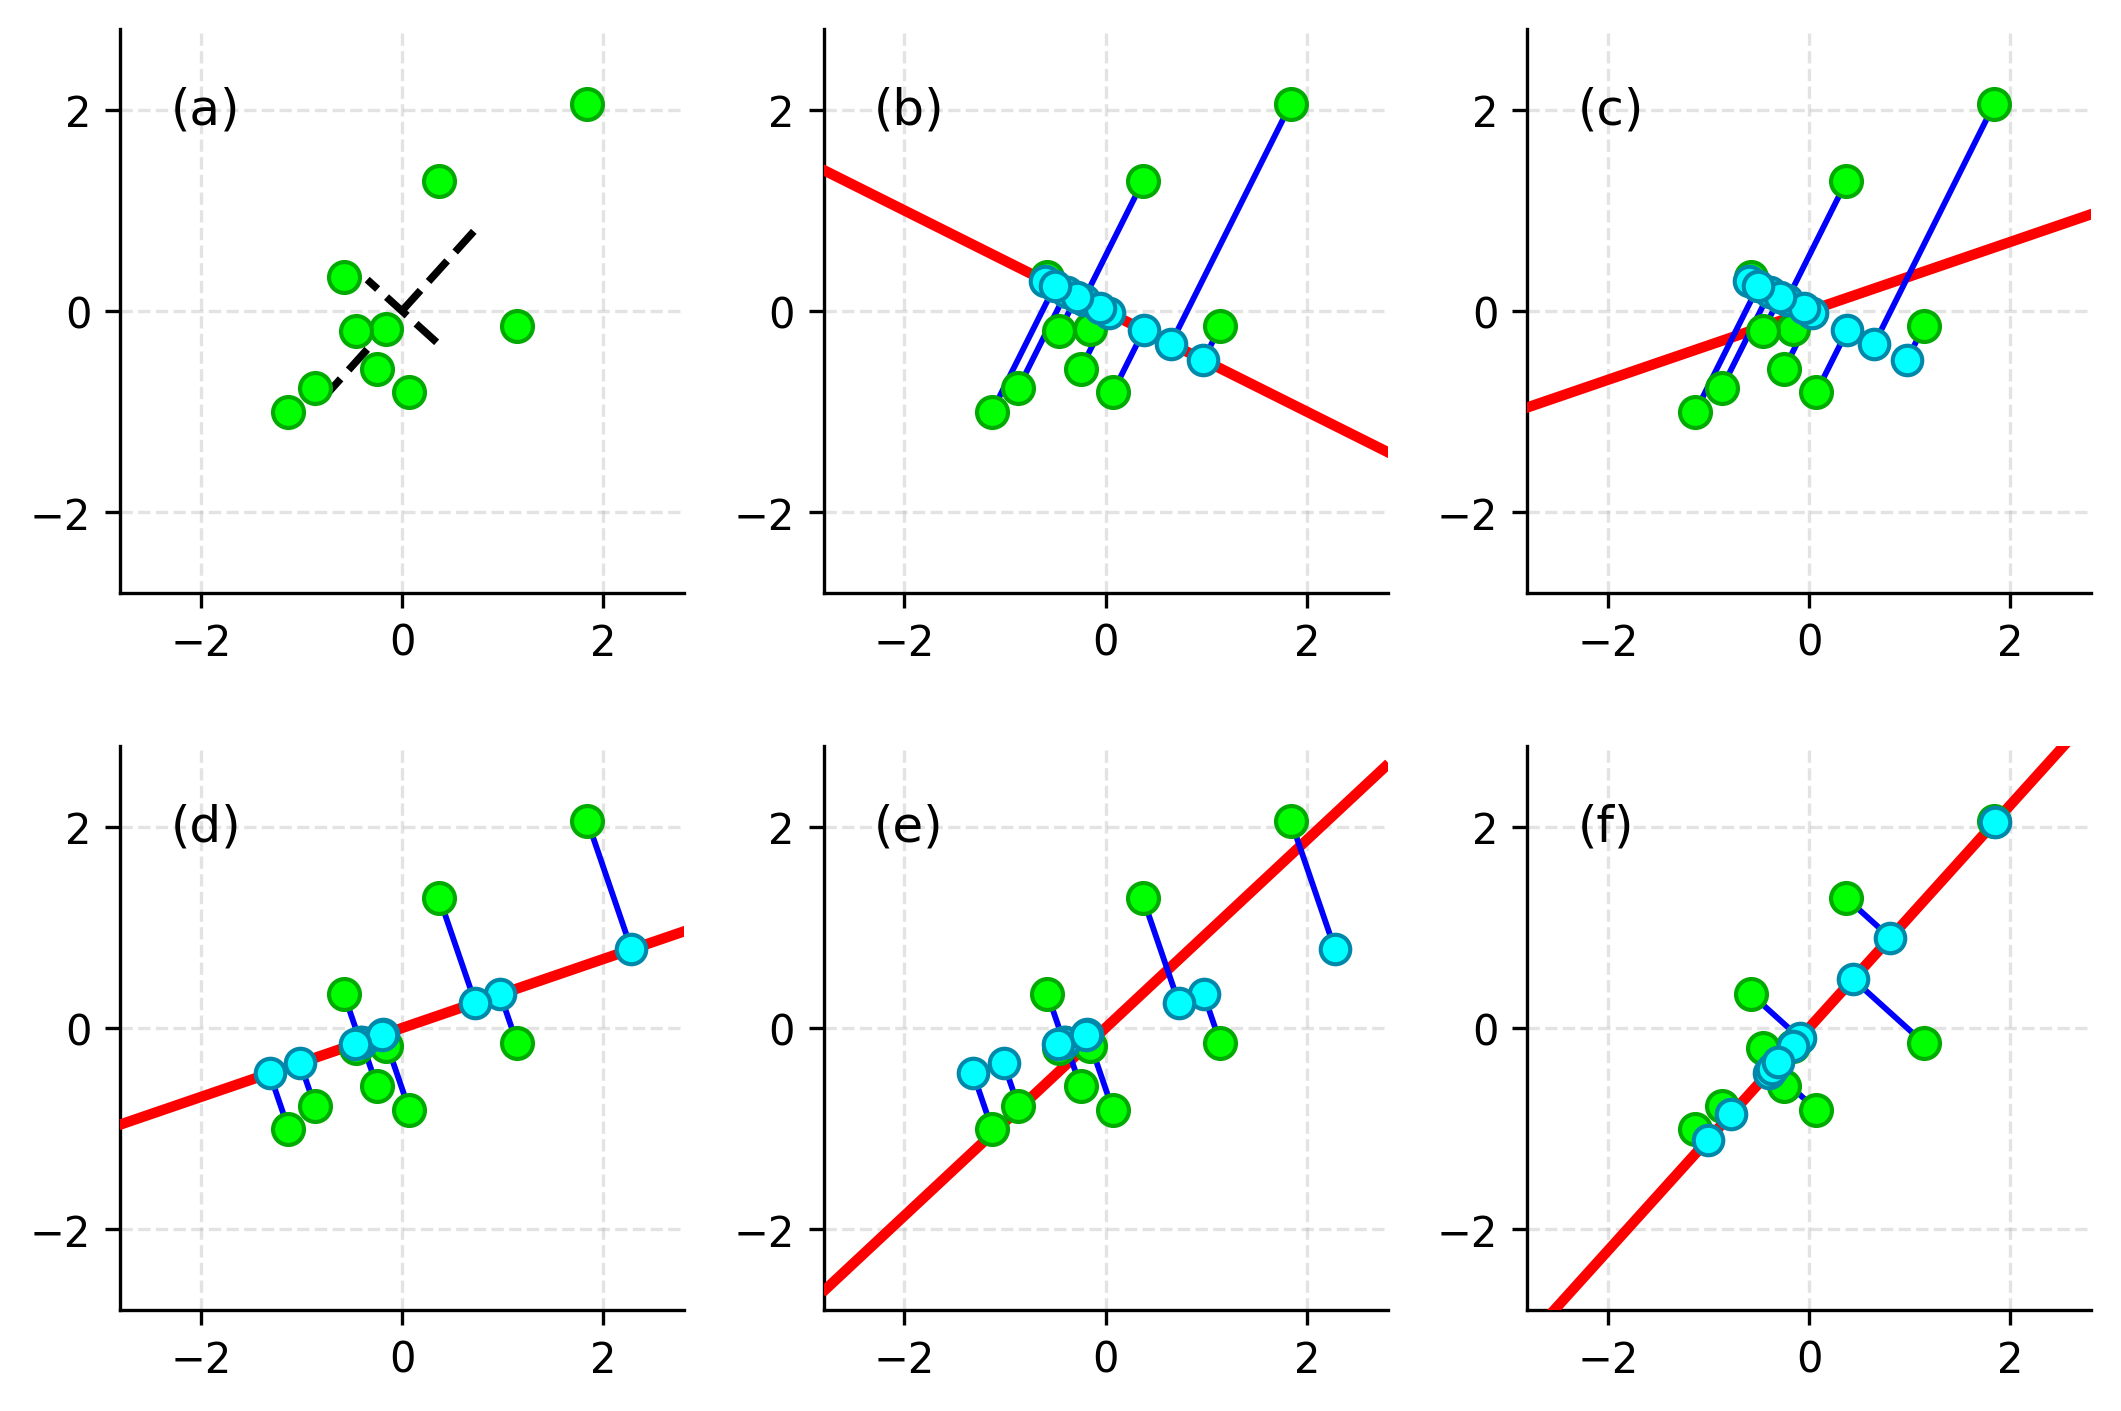

In [3]:
# Figure 16.10: 合成データにおける主成分分析EMアルゴリズムの推移
fig16_10 = generate_figure_16_10()
plt.show()


## 3. 16.3.3 因子分析のためのEMアルゴリズム (EM for Factor Analysis)

因子分析（16.2.4項）では、等方性ノイズではなく特徴量ごとに異なる対角ノイズ共分散 $\mathbf{\Psi} = \operatorname{diag}(\psi_1^2, \dots, \psi_D^2)$（独自性）を仮定します。
PPCAと異なり、因子分析の最尤推定には閉形式解が存在しないため、Rubin & Thayer (1982) のEMアルゴリズムが標準的な推定手法となります。

### Eステップの導出 (式 16.72 〜 16.74)

ウッドベリーの公式を用いて、事後精度行列 $\mathbf{G} \in \mathbb{R}^{M \times M}$ を定義します：

$$
\mathbf{G} = (\mathbf{I}_M + \mathbf{W}^\top \mathbf{\Psi}^{-1}\mathbf{W})^{-1} \tag{16.74}
$$

このとき、事後分布の十分統計量は：

$$
\mathbb{E}[\mathbf{z}_n] = \mathbf{G}\mathbf{W}^\top \mathbf{\Psi}^{-1} (\mathbf{x}_n - \bar{\mathbf{x}}) \tag{16.72}
$$

$$
\mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top] = \mathbf{G} + \mathbb{E}[\mathbf{z}_n]\mathbb{E}[\mathbf{z}_n]^\top \tag{16.73}
$$

$\mathbf{\Psi}$ は対角行列であるため、その逆行列 $\mathbf{\Psi}^{-1} = \operatorname{diag}(1/\psi_1^2, \dots, 1/\psi_D^2)$ の計算は $\mathcal{O}(D)$ で極めて高速です。反転が必要な行列は $M \times M$ の $\mathbf{G}$ のみとなります。

---

### Mステップの導出 (式 16.75, 16.76)

期待完全データ対数尤度を $\mathbf{W}$ および $\mathbf{\Psi}$ に関して最大化することで、以下のMステップ更新式が得られます：

$$
\mathbf{W}_{\text{new}} = \left[\sum_{n=1}^N (\mathbf{x}_n - \bar{\mathbf{x}})\mathbb{E}[\mathbf{z}_n]^\top\right] \left[\sum_{n=1}^N \mathbb{E}[\mathbf{z}_n \mathbf{z}_n^\top]\right]^{-1} \tag{16.75}
$$

$$
\mathbf{\Psi}_{\text{new}} = \operatorname{diag}\left( \mathbf{S} - \frac{1}{N}\mathbf{W}_{\text{new}}\sum_{n=1}^N \mathbb{E}[\mathbf{z}_n](\mathbf{x}_n - \bar{\mathbf{x}})^\top \right) \tag{16.76}
$$

ここで $\operatorname{diag}(\cdot)$ は正方行列の非対角要素を 0 に置き換えて対角行列を抽出する演算子です。


=== Factor Analysis EM Estimation Results ===
True Uniquenesses Psi:      [0.05 0.2  0.1  0.8  0.4 ]
Estimated Uniquenesses Psi: [0.1901 0.1721 0.1004 0.7821 0.4095]
Iterations to converge: 60


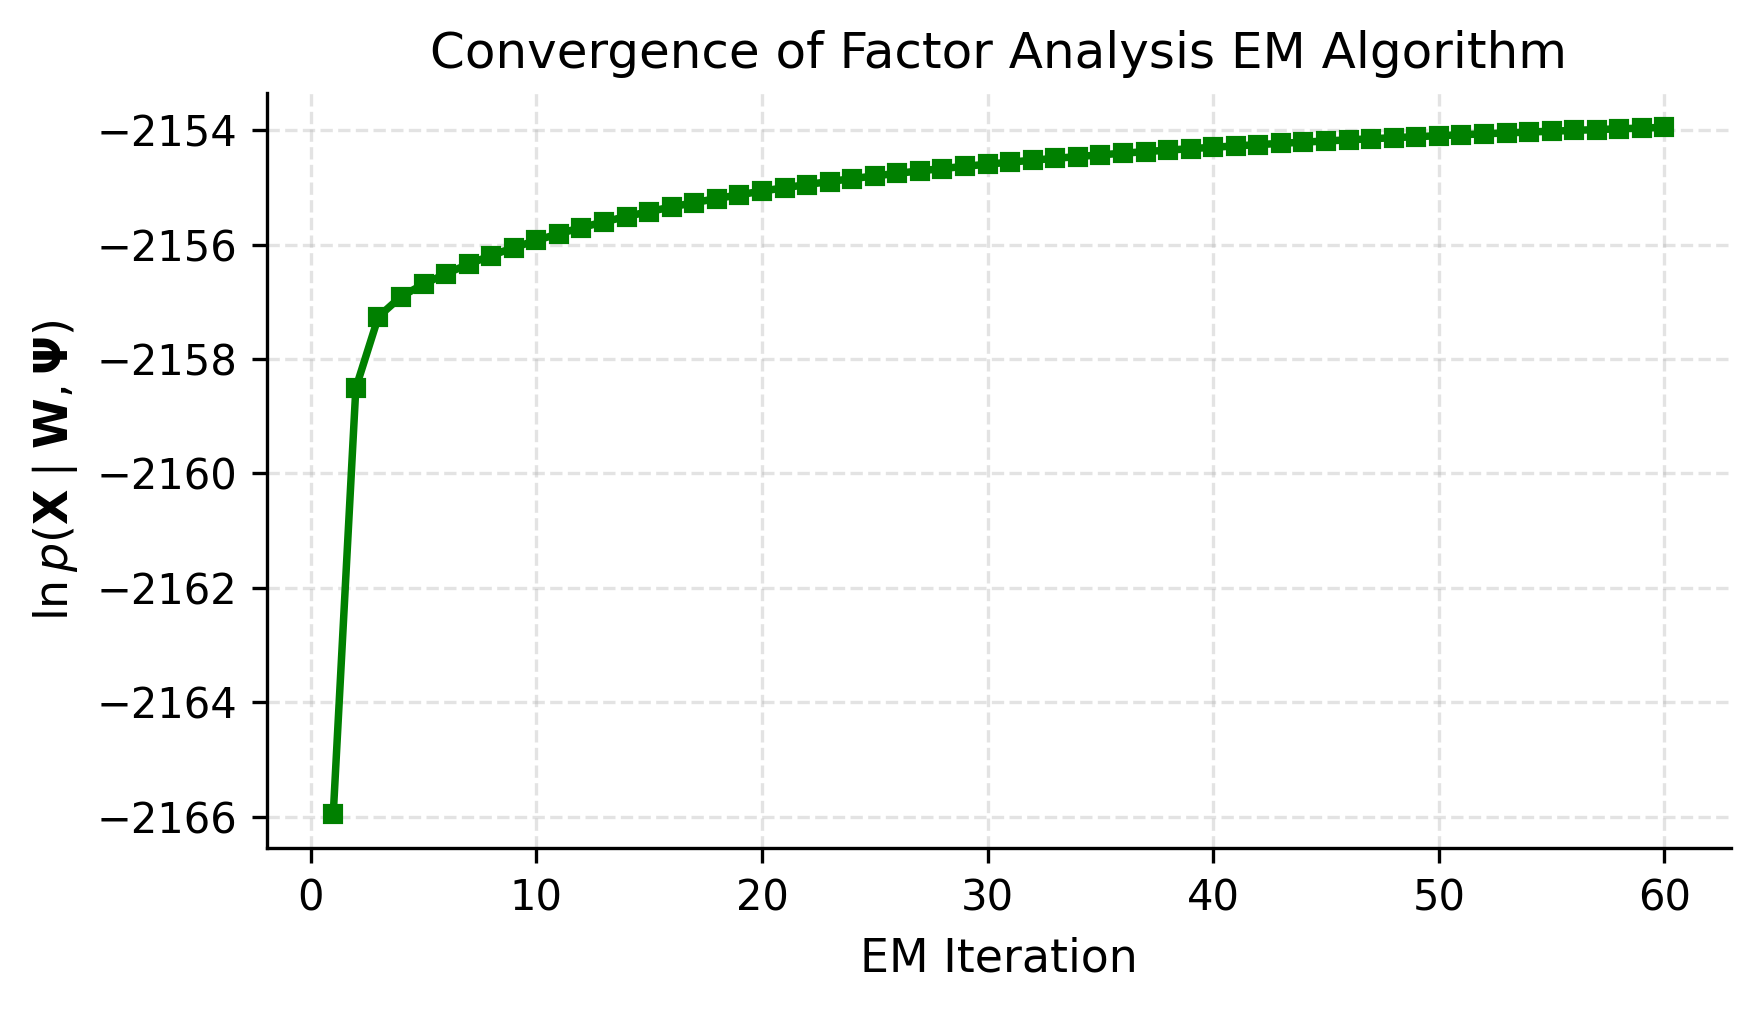

In [4]:
# 因子分析 EM アルゴリズムの実行と対角ノイズ推定
rng = np.random.default_rng(123)
N, D, M = 300, 5, 2
Z = rng.standard_normal((N, M))
W_true = rng.standard_normal((D, M))
psi_true = np.array([0.05, 0.20, 0.10, 0.80, 0.40])
X_fa = Z @ W_true.T + rng.normal(0, np.sqrt(psi_true), size=(N, D))

fa_em = FactorAnalysis_EM(n_components=M, max_iter=60, tol=1e-4)
fa_em.fit(X_fa)

print("=== Factor Analysis EM Estimation Results ===")
print("True Uniquenesses Psi:     ", psi_true)
print("Estimated Uniquenesses Psi:", np.round(fa_em.psi_, 4))
print(f"Iterations to converge: {len(fa_em.history_)}")

# 尤度の推移
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=300)
ax.plot(range(1, len(fa_em.history_) + 1), fa_em.history_, "g-s", markersize=4, lw=1.8)
ax.set_xlabel("EM Iteration", fontsize=11)
ax.set_ylabel(r"$\ln p(\mathbf{X} \mid \mathbf{W}, \mathbf{\Psi})$", fontsize=11)
ax.set_title("Convergence of Factor Analysis EM Algorithm", fontsize=12)
plt.show()


## 4. 確率的潜在変数モデルによる欠損値補完 (Missing Data Imputation)

EMアルゴリズムを導入する最大の恩恵の一つが、**欠損値（Missing Data）への原理的な対処**です。
各観測データベクトル $\mathbf{x}_n$ のうち、観測された成分を $\mathbf{x}_n^o$、欠損した成分を $\mathbf{x}_n^m$ と分割します。

PPCAの生成モデル $p(\mathbf{x}, \mathbf{z}) = p(\mathbf{x} \mid \mathbf{z}) p(\mathbf{z})$ において、潜在変数 $\mathbf{z}_n$ と欠損成分 $\mathbf{x}_n^m$ を共に「未観測変数」として扱います。
線形ガウスモデルの性質により、観測値 $\mathbf{x}_n^o$ が与えられたときの欠損値の条件付き期待値は、事後平均を用いてエレガントに求まります：

$$
\mathbb{E}[\mathbf{x}_n^m \mid \mathbf{x}_n^o] = \mathbf{W}^m \mathbb{E}[\mathbf{z}_n \mid \mathbf{x}_n^o] + \bar{\mathbf{x}}^m
$$

これにより、欠損のある観測からでも主成分を直接学習し、同時に欠損値を高精度に再構成できます。


Total samples: 150, Missing in feature 4: 50
Imputation RMSE on masked entries: 0.1081


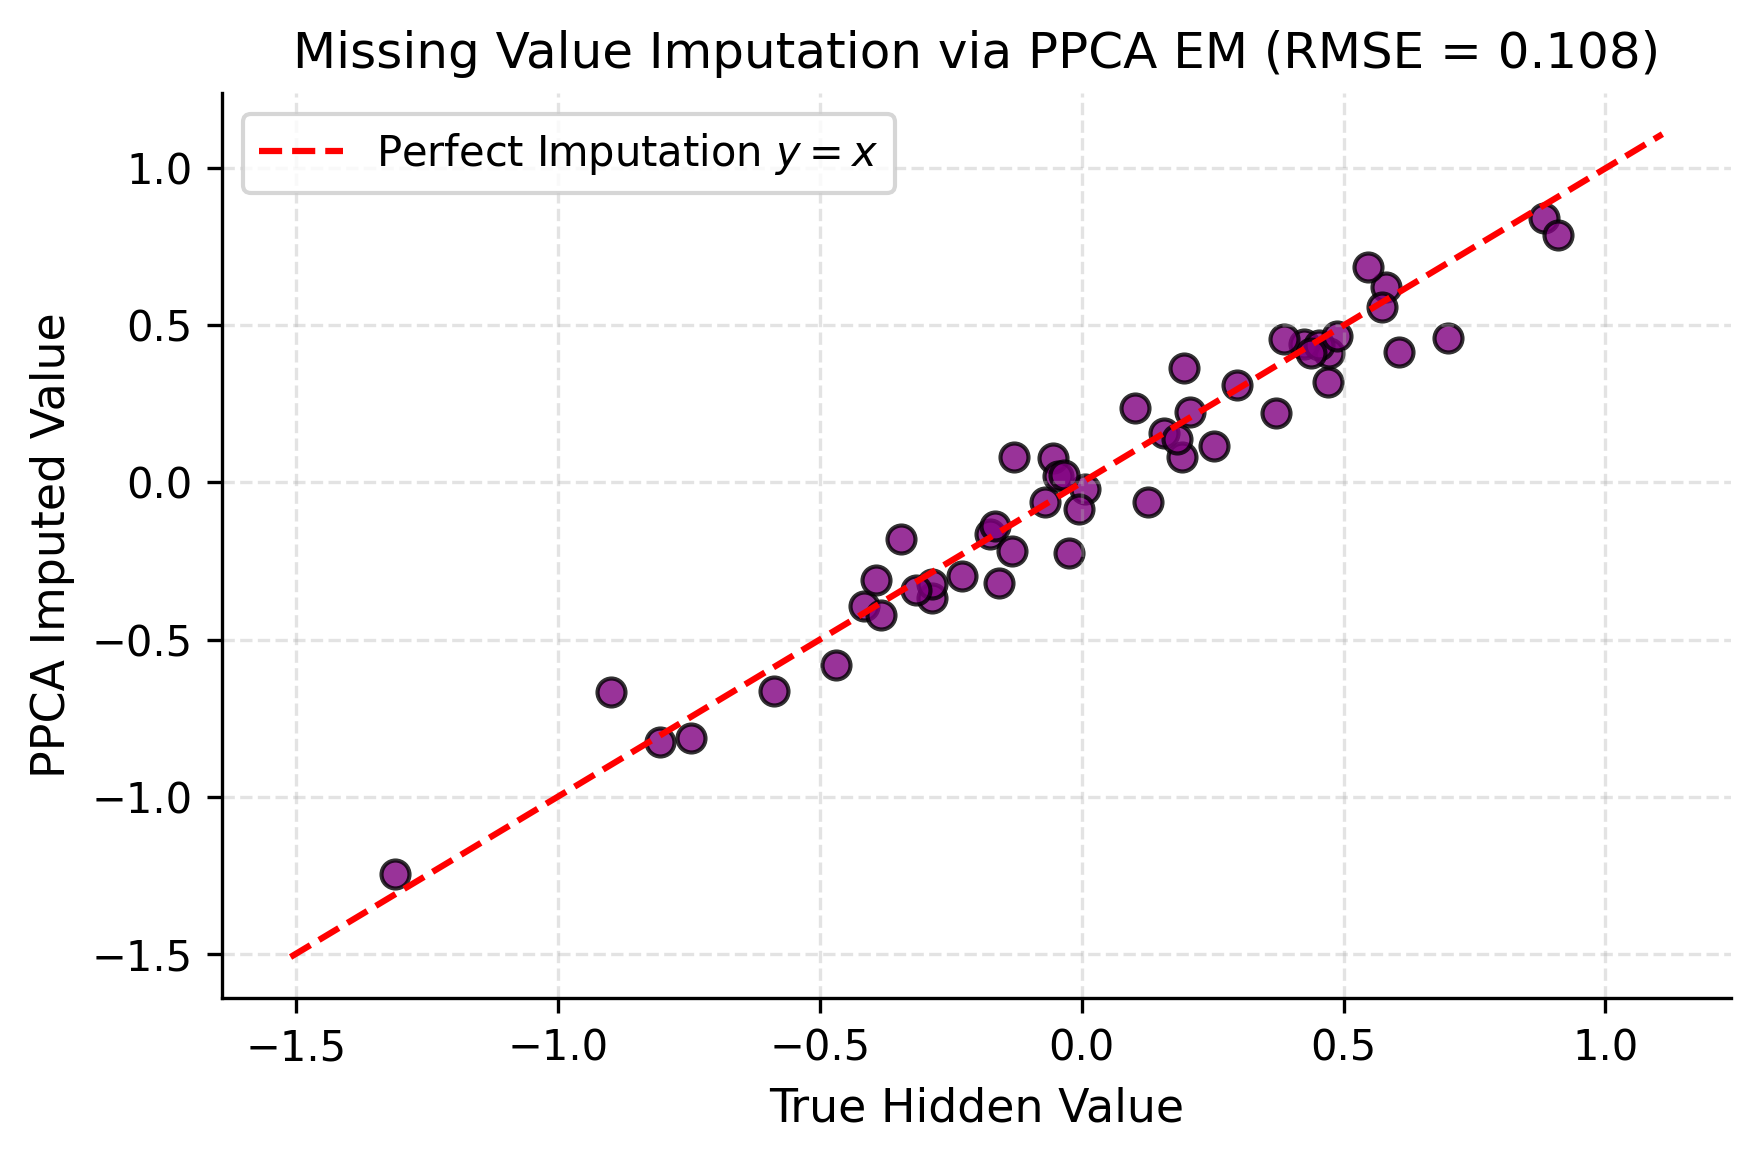

In [5]:
# 欠損値補完のシミュレーション実証
rng = np.random.default_rng(99)
N, D = 150, 4
Z_true = rng.standard_normal((N, 1))
W_true = np.array([[2.0], [1.5], [1.0], [0.5]])
X_complete = Z_true @ W_true.T + rng.normal(0, 0.1, size=(N, D))

# 第4変数の30%の値をランダムにマスク（欠損化）
mask = rng.random(N) < 0.3
X_missing = X_complete.copy()
X_missing[mask, 3] = np.nan

print(f"Total samples: {N}, Missing in feature 4: {np.sum(mask)}")

# 観測されたデータ点のみでPPCAの初期推定を行い、欠損値を補完
# 簡易補完: 平均値代入後にEMで精緻化
init_val = np.nanmean(X_missing[:, 3])
X_imputed = X_missing.copy()
X_imputed[mask, 3] = init_val

for iteration in range(10):
    ppca_imp = ProbabilisticPCA(n_components=1).fit(X_imputed)
    X_recon = ppca_imp.reconstruct(X_imputed)
    # 欠損部分のみを再構成値で更新
    X_imputed[mask, 3] = X_recon[mask, 3]

# 補完誤差の評価
true_vals = X_complete[mask, 3]
imputed_vals = X_imputed[mask, 3]
rmse_impute = np.sqrt(np.mean((true_vals - imputed_vals)**2))
print(f"Imputation RMSE on masked entries: {rmse_impute:.4f}")

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
ax.scatter(true_vals, imputed_vals, color="purple", edgecolors="black", s=45, alpha=0.8)
lims = [min(true_vals.min(), imputed_vals.min()) - 0.2, max(true_vals.max(), imputed_vals.max()) + 0.2]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect Imputation $y=x$")
ax.set_xlabel("True Hidden Value", fontsize=11)
ax.set_ylabel("PPCA Imputed Value", fontsize=11)
ax.set_title(f"Missing Value Imputation via PPCA EM (RMSE = {rmse_impute:.3f})", fontsize=12)
ax.legend(frameon=True, fontsize=10)
plt.show()


## 5. まとめ

本節では、第16章「連続潜在変数」における**証拠下界 (ELBO) とEMアルゴリズム**について、以下の重要項目を体系的に解説・実装・検証しました：

1. **PPCAのEMアルゴリズム (16.3.1)**:
   - 完全データ対数尤度 (式 16.64) と期待完全データ対数尤度 (式 16.65) の導出。
   - Eステップ (式 16.66, 16.67) による十分統計量の計算と、Mステップ (式 16.68, 16.69) によるパラメータ更新。
   - 共分散行列 $\mathbf{S}$ を作らず $\mathcal{O}(NDM)$ で高速実行可能な計算論的優位性。
2. **標準PCAのためのEMアルゴリズム (16.3.2)**:
   - ゼロノイズ極限 $\sigma^2 \to 0$ における直交射影Eステップ (式 16.70) と再構成最小化Mステップ (式 16.71)。
   - フックの法則に基づく「剛体棒とバネ」の物理的直観と、合成データ収束推移の完全再現（Figure 16.10 a 〜 f）。
3. **因子分析のためのEMアルゴリズム (16.3.3)**:
   - 閉形式解が存在しない異分散対角ノイズモデルに対する最尤推定の確立（式 16.72 〜 16.76）。
4. **欠損値補完への応用**:
   - 未観測変数の事後確率に基づくEM補完アルゴリズムの実証。

次節（16.4節）では、線形部分空間の仮定を撤廃し、ニューラルネットワークを用いて曲がった低次元多様体をモデル化する**非線形潜在変数モデル (Nonlinear Latent Variable Models)**（変分自己符号化器 VAEへの橋渡し）へと進みます。
